<a href="https://colab.research.google.com/github/orchid-initiative/postpartum-larc/blob/main/analysis/larc_analysis_presentation_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import libraries
import pandas
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
# connect the collab notebook to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# load the data from google drive
larc_dataset = pandas.read_csv("/content/drive/MyDrive/Immediate Post-Partum LARC Utilization/sample aggregations/labor_and_delivery_SUMMARY_2024_20240703.csv")

In [4]:

def larc_stats(col, df):
  '''collate statistics from selected col of df from the larc statistics dataset'''

  # initalize output dictionaries
  stat = {}
  stat_larc = {}

  # iterate through the dataset
  # NOTE: iterrows is relatively slow
  for index, row in df.iterrows():

    if row[col] not in stat:
      # initialize the key in the output dictionaries
      stat[row[col]] = 0
      stat_larc[row[col]] = 0

    # save the values into the dictionary
    stat[row[col]] += row["l_and_d_incl"]
    stat_larc[row[col]] += row["larc"]

  return(stat, stat_larc)

In [5]:
# collect results by hospital name
hospital_name, hospital_name_larc = larc_stats("hospital_name", larc_dataset)
hospital_name_larc_rates = {key: (val * 100) / hospital_name[key] for key, val in hospital_name_larc.items()}

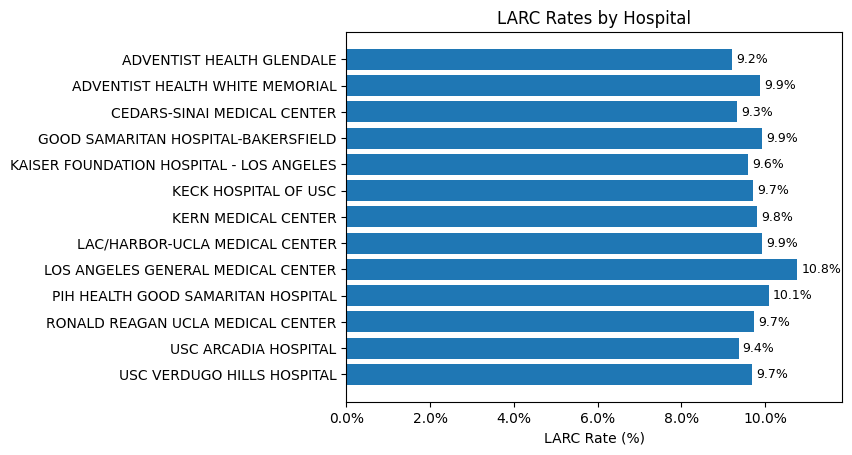

In [7]:
# use default visual style
plt.style.use("default")

# set titles and axis labels
plt.title("LARC Rates by Hospital")
plt.xlabel("LARC Rate (%)")

# sort data alphabetically by hospital name
sorted_data = dict(sorted(hospital_name_larc_rates.items(),
                          key = lambda x: x[0],
                          reverse = True))
names = list(sorted_data.keys())
values = list(sorted_data.values())

# plot the values as horizontal bars
bars = plt.barh(names, values)

# set the axis ticks to display as percentages
ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

# adjust the right margin for visibility
ax.set_xlim(0, max(values) * 1.1)

# plot the precise value of each bar alongside the bar
for bar in bars:
  plt.text(
      bar.get_width() + 0.1,
      bar.get_y() + bar.get_height() / 2,
      f"{bar.get_width():.1f}%",
      va="center",
      fontsize = 9,
  )

In [ ]:
# save the hospital by-year larc rate data into a new variable
df_grouped = hospital_by_year_larc_rate

# add the larc rate (in %) to the dataset
df_grouped["larc_rate"] = df_grouped["larc"] / df_grouped["l_and_d_incl"]
# filter for values after 2015 as earlier year data is poor quality
df_grouped = df_grouped[df_grouped.index.get_level_values("dsch_yr") >= 2015]


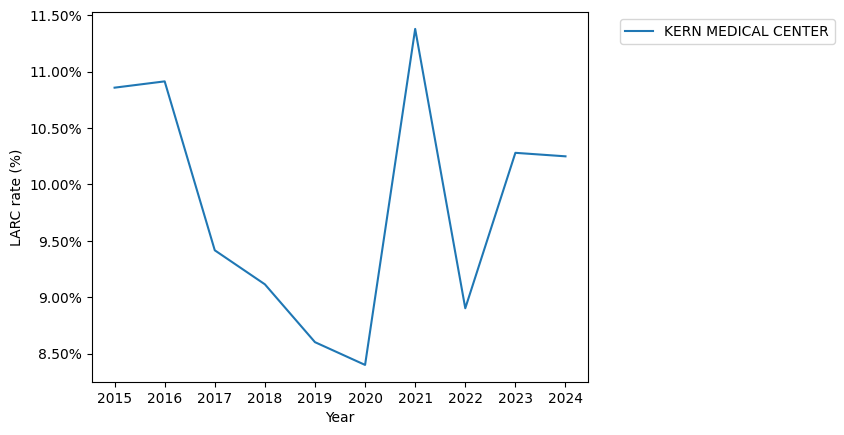

In [ ]:
# reset the indicies and column labels for ease of use
plot_df = df_grouped.reset_index()

# select one hospital as an example - using all hospitals is too cluttered
hospital = "KERN MEDICAL CENTER"
hospital_df = plot_df[plot_df["hospital_name"] == hospital]

# initialize graph
fig, ax = plt.subplots()

# plot the values as a line graph
ax = plt.gca()
for hospital, data in hospital_df.groupby("hospital_name"):
  plt.plot(
      data["dsch_yr"],
      data["larc_rate"],
      label = hospital
  )

# make sure there is an x axis label for every year
years = sorted(plot_df["dsch_yr"].unique())
ax.set_xticks(years)
plt.xlabel("Year")

# display the y axis label in %
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

# axis labels
plt.ylabel("LARC rate (%)")

# display the legend
plt.legend(bbox_to_anchor=(1.05, 1), loc = "upper left")

# display graph
plt.show()